<a href="https://colab.research.google.com/github/isocan/Pt111-MACE/blob/main/Pt111_O_OH_OOH_MACE_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pt(111) adsorption with MACE: O*, OH* and OOH*

**A Google Colab tutorial for screening ORR/OER intermediates on Pt(111)**

This notebook builds a Pt(111) slab, generates several adsorption-site and orientation guesses, relaxes every candidate with a MACE foundation model, audits the relaxed structures, and evaluates balanced electronic adsorption energies using H$_2$ and H$_2$O references.

You will learn how to:

1. use MACE-MH-1 as an ASE calculator;
2. construct and constrain a periodic Pt(111) slab;
3. search ontop, bridge, fcc and hcp starting sites;
4. detect non-convergence, short contacts, O–H/O–O bond breaking and **chemical slip**;
5. calculate $\Delta E_{\mathrm{O*}}$, $\Delta E_{\mathrm{OH*}}$, and $\Delta E_{\mathrm{OOH*}}$ with atom-balanced H$_2$/H$_2$O cycles;
6. export the best structures for DFT validation.

**Recommended runtime:** in Colab select **Runtime → Change runtime type → T4 GPU**, then run the cells in order.


## Scientific scope and limitations

This is a **MLIP screening calculation**, not a publication-ready Pt electrocatalysis result.

- The default calculator is **MACE-MH-1**, `omat_pbe` head, used consistently for the slab and gas-phase references. Do not combine absolute energies from different heads or models.
- The model has no electrode potential, explicit solvent, electrolyte, surface charge, or constant-potential boundary condition in this workflow.
- The reported quantities are electronic energy differences, $\Delta E$. They do **not** include zero-point energy, entropy, solvation, field, coverage or potential corrections.
- OOH* has several possible orientations. Four sites and multiple azimuths are searched, but this is not an exhaustive global optimization.
- A relaxed MLIP minimum can be chemically wrong. We therefore retain site migration as information, flag dissociation, and export the best candidates for a DFT residual-force/single-point check.

The workflow follows the spirit of Fako *et al.*: use MLIPs to relax many candidates, then validate selected structures with DFT. Their work also emphasizes “chemical slip,” where the intended and relaxed adsorption sites differ.

**Primary resources:** [MACE repository](https://github.com/ACEsuit/mace), [MACE foundation-model guide](https://mace-docs.readthedocs.io/en/latest/guide/foundation_models.html), [MACE-MH-1 model card](https://huggingface.co/mace-foundations/mace-mh-1), [Fako *et al.* active-learning workflow](https://arxiv.org/abs/2301.09931), [AdsMind/chemical-slip study](https://arxiv.org/abs/2606.19152), and [AutoAdsorbate](https://github.com/basf/autoadsorbate).


## 1. Install the calculation stack

`mace-torch` supplies the potential and ASE calculator; ASE supplies structure construction, optimizers and file writers. MACE-MH-1 support requires a recent MACE release.


In [1]:
%pip install -q "mace-torch>=0.3.14" "ase>=3.23" pandas matplotlib


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.0/316.0 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.7/387.7 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 221.0/221.0 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.7/344.7 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 453.1/453.1 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 3.5 MB/s eta 0:00:00


## 2. Imports and editable settings

The default 3×4 surface cell and four Pt layers are reasonable for a tutorial. For production, test a larger cell, more layers, denser site/orientation sampling, tighter force tolerance and model/DFT convergence.


In [2]:
from pathlib import Path
import math
import shutil
import time
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from ase import Atoms
from ase.build import add_adsorbate, fcc111, molecule
from ase.constraints import FixAtoms
from ase.geometry import find_mic
from ase.io import read, write
from ase.optimize import FIRE
from ase.visualize.plot import plot_atoms

warnings.filterwarnings("ignore", message=".*default.*dtype.*")

# ----- Model -----
MODEL_ALIAS = "mh-1"
MODEL_HEAD = "omat_pbe"   # balanced cross-domain head; keep one head throughout
DEFAULT_DTYPE = "float32"
DISPERSION = False
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ----- Pt(111) slab -----
PT_LATTICE_A = 3.92        # Angstrom; test/optimize for production work
SLAB_SIZE = (3, 4, 4)      # (surface repeats x, y, Pt layers); y must be even here
VACUUM_A = 15.0
FIX_BOTTOM_LAYERS = 2

# ----- Candidate search -----
SITES = ["ontop", "bridge", "fcc", "hcp"]
OOH_AZIMUTHS_DEG = [0.0, 120.0, 240.0]
ADSORBATE_HEIGHT_A = {"O": 1.70, "OH": 1.85, "OOH": 2.00}

# Set True for a shorter first run; set False for the tighter tutorial defaults.
FAST_MODE = False
FMAX_EV_A = 0.08 if FAST_MODE else 0.05
MAX_STEPS = 160 if FAST_MODE else 300
OOH_AZIMUTHS_RUN = [0.0] if FAST_MODE else OOH_AZIMUTHS_DEG

RESULTS = Path("pt111_mace_results")
RESULTS.mkdir(exist_ok=True)

print(f"Device: {DEVICE}")
print(f"Candidates: {4 + 4 + 4 * len(OOH_AZIMUTHS_RUN)} plus slab and references")
print(f"Force target: {FMAX_EV_A:.3f} eV/Angstrom")


Device: cuda
Candidates: 20 plus slab and references
Force target: 0.050 eV/Angstrom


## 3. Load MACE-MH-1

The current MACE calculator recognizes the `mh-1` alias. A direct official-release download is included as a fallback. The first run downloads and caches the model, so it can take a few minutes.

`omat_pbe` is selected because it is the model card's balanced cross-domain head. An `oc20_usemppbe` surface-catalysis head also exists, but changing heads changes the learned energy function; all terms in an atom-balanced energy cycle must use one consistent head.


In [3]:
from mace.calculators import mace_mp

def load_mace_calculator():
    kwargs = dict(
        device=DEVICE,
        default_dtype=DEFAULT_DTYPE,
        head=MODEL_HEAD,
        dispersion=DISPERSION,
    )
    try:
        print(f"Loading MACE alias {MODEL_ALIAS!r}, head {MODEL_HEAD!r} ...")
        return mace_mp(model=MODEL_ALIAS, **kwargs)
    except Exception as alias_error:
        print("Alias loading failed; trying the official MACE foundation release ...")
        print("Alias error:", type(alias_error).__name__, str(alias_error)[:250])
        model_path = Path("mace-mh-1.model")
        if not model_path.exists():
            url = (
                "https://github.com/ACEsuit/mace-foundations/releases/download/"
                "mace_mh_1/mace-mh-1.model"
            )
            urllib.request.urlretrieve(url, model_path)
        return mace_mp(model=str(model_path), **kwargs)

calc = load_mace_calculator()
print("Calculator ready:", type(calc).__name__)


/usr/local/lib/python3.12/dist-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Loading MACE alias 'mh-1', head 'omat_pbe' ...
Downloading: 100.0% (56.5 MB / 56.5 MB)
Cached MACE model to /root/.cache/mace/macemh1model
Using Materials Project MACE for MACECalculator with /root/.cache/mace/macemh1model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Calculator ready: MACECalculator


## 4. Build Pt(111) and the adsorbates

ASE assigns layer tags to the Pt slab. The bottom two layers are fixed while the upper two layers and adsorbate relax. O is the anchoring atom (`mol_index=0`) for OH and OOH. Initial molecular geometries are only starting guesses.


In [4]:
def build_pt111():
    slab = fcc111(
        "Pt",
        size=SLAB_SIZE,
        a=PT_LATTICE_A,
        vacuum=VACUUM_A,
        orthogonal=True,
        periodic=True,
    )
    # fcc111 tags: top layer = 1, next = 2, ...
    fixed = [i for i, atom in enumerate(slab) if atom.tag > SLAB_SIZE[2] - FIX_BOTTOM_LAYERS]
    slab.set_constraint(FixAtoms(indices=fixed))
    slab.info["n_slab"] = len(slab)
    slab.info["fixed_indices"] = fixed
    return slab


def make_adsorbate(name):
    if name == "O":
        return Atoms("O", positions=[[0.0, 0.0, 0.0]])
    if name == "OH":
        # O anchored to Pt, H pointing initially away from the surface.
        return Atoms("OH", positions=[[0.0, 0.0, 0.0], [0.0, 0.0, 0.98]])
    if name == "OOH":
        # Surface O at index 0; O-O = 1.45 A and terminal O-H ~= 0.96 A.
        return Atoms(
            "OOH",
            positions=[
                [0.0, 0.0, 0.0],
                [0.0, 0.0, 1.45],
                [0.85, 0.0, 1.90],
            ],
        )
    raise ValueError(f"Unknown adsorbate: {name}")


def build_candidate(relaxed_clean_slab, adsorbate, site, azimuth_deg=0.0):
    atoms = relaxed_clean_slab.copy()
    atoms.calc = None
    ads = make_adsorbate(adsorbate)
    if len(ads) > 1 and azimuth_deg:
        ads.rotate(azimuth_deg, "z", center=ads.positions[0], rotate_cell=False)
    add_adsorbate(
        atoms,
        ads,
        height=ADSORBATE_HEIGHT_A[adsorbate],
        position=site,
        mol_index=0,
    )
    atoms.wrap()
    atoms.info.update(
        adsorbate=adsorbate,
        start_site=site,
        azimuth_deg=float(azimuth_deg),
        n_slab=len(relaxed_clean_slab),
    )
    return atoms


slab0 = build_pt111()
print(slab0)
print("Fixed Pt atoms:", len(slab0.constraints[0].get_indices()))


Atoms(symbols='Pt48', pbc=True, cell=[8.3155757467538, 9.601999791710057, 36.78963916566999], tags=..., constraint=FixAtoms(indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]))
Fixed Pt atoms: 24


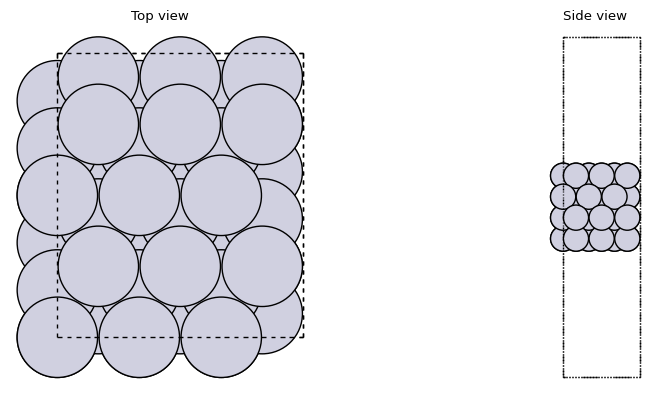

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_atoms(slab0, axes[0], rotation="0x,0y,0z", show_unit_cell=2)
axes[0].set_title("Top view")
plot_atoms(slab0, axes[1], rotation="90x,0y,0z", show_unit_cell=2)
axes[1].set_title("Side view")
for ax in axes:
    ax.set_axis_off()
plt.tight_layout()
plt.show()


## 5. Geometry-relaxation and audit helpers

The audit deliberately distinguishes a **starting label** from the **final site family**. fcc and hcp are both reported as `hollow` after relaxation because a simple lateral projection cannot reliably distinguish their subsurface stacking. Site migration does not automatically invalidate a result; it means the relaxed minimum should be relabeled.

Molecular integrity is stricter: an OH or OOH candidate with a broken O–H or O–O bond is excluded from the intact-intermediate minimum. A dissociated product may still be interesting, but it represents a different reaction state.


In [6]:
def constrained_indices(atoms):
    indices = set()
    for constraint in atoms.constraints:
        if hasattr(constraint, "get_indices"):
            indices.update(map(int, constraint.get_indices()))
    return sorted(indices)


def relax_atoms(atoms, label, fmax=FMAX_EV_A, steps=MAX_STEPS):
    atoms = atoms.copy()
    atoms.calc = calc
    traj = RESULTS / f"{label}.traj"
    opt = FIRE(atoms, trajectory=str(traj), logfile=None)
    t0 = time.time()
    converged = bool(opt.run(fmax=fmax, steps=steps))
    energy = float(atoms.get_potential_energy())
    forces = atoms.get_forces(apply_constraint=True)
    max_force = float(np.linalg.norm(forces, axis=1).max())
    elapsed_s = time.time() - t0
    write(RESULTS / f"{label}.extxyz", atoms)
    return atoms, {
        "converged": converged,
        "energy_eV": energy,
        "max_force_eVA": max_force,
        "steps": int(opt.nsteps),
        "elapsed_s": elapsed_s,
    }


def top_layer_pt_indices(atoms, n_slab):
    pt = [i for i in range(n_slab) if atoms[i].symbol == "Pt"]
    zmax = max(atoms.positions[i, 2] for i in pt)
    return [i for i in pt if atoms.positions[i, 2] > zmax - 0.60]


def lateral_distances_to_top_pt(atoms, anchor_index, n_slab):
    top = top_layer_pt_indices(atoms, n_slab)
    vectors = []
    for i in top:
        v = atoms.positions[i] - atoms.positions[anchor_index]
        v[2] = 0.0
        vectors.append(v)
    mic_vectors, _ = find_mic(
        np.asarray(vectors), atoms.cell, pbc=(True, True, False)
    )
    return np.sort(np.linalg.norm(mic_vectors[:, :2], axis=1))


def classify_final_site(atoms, n_slab):
    anchor = n_slab  # first adsorbate atom is the anchoring O
    d = lateral_distances_to_top_pt(atoms, anchor, n_slab)
    if d[0] < 0.60:
        return "ontop"
    if d[1] < 1.65 and d[2] > 1.75:
        return "bridge"
    if d[2] < 1.80:
        return "hollow"
    return "other"


def expected_site_family(site):
    return "hollow" if site in {"fcc", "hcp"} else site


def adsorbate_bonds(atoms, adsorbate, n_slab):
    # The adsorbate atoms are appended in make_adsorbate order.
    if adsorbate == "O":
        return {}, True
    if adsorbate == "OH":
        d_oh = float(atoms.get_distance(n_slab, n_slab + 1, mic=True))
        return {"d_OH_A": d_oh}, d_oh < 1.30
    if adsorbate == "OOH":
        d_oo = float(atoms.get_distance(n_slab, n_slab + 1, mic=True))
        d_oh = float(atoms.get_distance(n_slab + 1, n_slab + 2, mic=True))
        return {"d_OO_A": d_oo, "d_OH_A": d_oh}, (d_oo < 1.90 and d_oh < 1.30)
    raise ValueError(adsorbate)


def minimum_distance(atoms):
    distances = atoms.get_all_distances(mic=True)
    distances[distances < 1e-12] = np.inf
    return float(distances.min())


def slab_rms_displacement(initial, final, n_slab):
    movable_pt = [i for i in range(n_slab) if i not in constrained_indices(final)]
    vectors = final.positions[movable_pt] - initial.positions[movable_pt]
    mic_vectors, _ = find_mic(vectors, final.cell, pbc=final.pbc)
    return float(np.sqrt(np.mean(np.sum(mic_vectors**2, axis=1))))


def audit_candidate(initial, relaxed, record):
    n_slab = int(relaxed.info["n_slab"])
    adsorbate = relaxed.info["adsorbate"]
    site = relaxed.info["start_site"]
    bonds, intact = adsorbate_bonds(relaxed, adsorbate, n_slab)
    final_site = classify_final_site(relaxed, n_slab)
    record.update(
        final_site_family=final_site,
        chemical_slip=(final_site != expected_site_family(site)),
        bond_intact=bool(intact),
        min_distance_A=minimum_distance(relaxed),
        slab_rmsd_A=slab_rms_displacement(initial, relaxed, n_slab),
        **bonds,
    )
    record["valid_intact_minimum"] = bool(
        record["converged"]
        and record["bond_intact"]
        and record["min_distance_A"] > 0.65
        and record["max_force_eVA"] <= FMAX_EV_A * 1.05
    )
    return record


## 6. Relax H₂ and H₂O references

Closed-shell H$_2$/H$_2$O cycles avoid using an isolated O, OH or OOH radical as the direct reference. This is especially important because the present calculator call does not take explicit molecular charge or spin as an input.

These molecular calculations must still use the **same MACE model and head** as the surface calculations.


In [7]:
def boxed_molecule(name, box_A=18.0):
    atoms = molecule(name)
    atoms.set_cell([box_A, box_A, box_A])
    atoms.set_pbc(False)
    atoms.center()
    return atoms


reference_structures = {
    "H2": boxed_molecule("H2"),
    "H2O": boxed_molecule("H2O"),
}
reference_energies = {}

for name, atoms in reference_structures.items():
    relaxed, info = relax_atoms(atoms, f"reference_{name}")
    reference_structures[name] = relaxed
    reference_energies[name] = info["energy_eV"]
    print(
        f"{name:3s}: E = {info['energy_eV']: .6f} eV, "
        f"converged = {info['converged']}, max|F| = {info['max_force_eVA']:.4f} eV/A"
    )


H2 : E = -6.766249 eV, converged = True, max|F| = 0.0408 eV/A
H2O: E = -14.228680 eV, converged = True, max|F| = 0.0306 eV/A


## 7. Relax the clean Pt(111) slab

All adsorbate candidates start from this same relaxed clean slab. This makes the energy cycle internally consistent and reduces irrelevant slab-strain differences.


In [8]:
clean_slab, clean_info = relax_atoms(slab0, "clean_Pt111")
E_CLEAN = clean_info["energy_eV"]
print(pd.Series(clean_info))


converged              True
energy_eV       -278.403473
max_force_eVA      0.034713
steps                     9
elapsed_s           1.78958
dtype: object


/usr/local/lib/python3.12/dist-packages/ase/io/extxyz.py:320: UserWarning: Skipping unhashable information adsorbate_info
  warnings.warn('Skipping unhashable information '


## 8. Generate and relax the adsorption candidates

This is the expensive cell. With `FAST_MODE=False`, it relaxes four guesses for O*, four for OH*, and twelve for OOH*. Candidate energies are comparable **only within the same adsorbate stoichiometry** until the balanced reference equations are applied later.


In [9]:
candidate_specs = []
for adsorbate in ["O", "OH", "OOH"]:
    angles = OOH_AZIMUTHS_RUN if adsorbate == "OOH" else [0.0]
    for site in SITES:
        for angle in angles:
            candidate_specs.append((adsorbate, site, angle))

records = []
relaxed_structures = {}

for number, (adsorbate, site, angle) in enumerate(candidate_specs, start=1):
    label = f"{adsorbate}_{site}_a{angle:g}".replace(".", "p")
    initial = build_candidate(clean_slab, adsorbate, site, angle)
    print(f"[{number:02d}/{len(candidate_specs):02d}] {label}", end=" ... ")
    try:
        relaxed, info = relax_atoms(initial, label)
        record = {
            "adsorbate": adsorbate,
            "start_site": site,
            "azimuth_deg": angle,
            "label": label,
            **info,
        }
        record = audit_candidate(initial, relaxed, record)
        relaxed.calc = None
        relaxed_structures[label] = relaxed
        records.append(record)
        print(
            f"E={record['energy_eV']:.5f} eV; "
            f"site={record['final_site_family']}; "
            f"valid={record['valid_intact_minimum']}"
        )
    except Exception as error:
        records.append(
            {
                "adsorbate": adsorbate,
                "start_site": site,
                "azimuth_deg": angle,
                "label": label,
                "converged": False,
                "valid_intact_minimum": False,
                "error": f"{type(error).__name__}: {error}",
            }
        )
        print("FAILED:", records[-1]["error"])

candidates = pd.DataFrame(records)
candidates.to_csv(RESULTS / "all_candidates.csv", index=False)
candidates


[01/20] O_ontop_a0 ... E=-283.24380 eV; site=ontop; valid=True
[02/20] O_bridge_a0 ... E=-284.13892 eV; site=hollow; valid=True
[03/20] O_fcc_a0 ... E=-284.14182 eV; site=hollow; valid=True
[04/20] O_hcp_a0 ... E=-283.91754 eV; site=hollow; valid=True
[05/20] OH_ontop_a0 ... E=-288.42340 eV; site=ontop; valid=True
[06/20] OH_bridge_a0 ... E=-288.18723 eV; site=bridge; valid=True
[07/20] OH_fcc_a0 ... E=-287.91483 eV; site=hollow; valid=True
[08/20] OH_hcp_a0 ... E=-287.71371 eV; site=hollow; valid=True
[09/20] OOH_ontop_a0 ... E=-292.63269 eV; site=ontop; valid=True
[10/20] OOH_ontop_a120 ... E=-292.63354 eV; site=ontop; valid=True
[11/20] OOH_ontop_a240 ... E=-292.63510 eV; site=ontop; valid=True
[12/20] OOH_bridge_a0 ... E=-292.38071 eV; site=bridge; valid=True
[13/20] OOH_bridge_a120 ... E=-292.37830 eV; site=bridge; valid=True
[14/20] OOH_bridge_a240 ... E=-292.72119 eV; site=ontop; valid=False
[15/20] OOH_fcc_a0 ... E=-292.20740 eV; site=hollow; valid=True
[16/20] OOH_fcc_a120 ...

,adsorbate,start_site,azimuth_deg,label,converged,energy_eV,max_force_eVA,steps,elapsed_s,final_site_family,chemical_slip,bond_intact,min_distance_A,slab_rmsd_A,valid_intact_minimum,d_OH_A,d_OO_A
0,O,ontop,0.0,O_ontop_a0,True,-283.243805,0.041493,38,2.563746,ontop,False,True,1.813039,0.049037,True,NaN,NaN
1,O,bridge,0.0,O_bridge_a0,True,-284.138916,0.049768,80,5.574998,hollow,True,True,2.055646,0.058060,True,NaN,NaN
2,O,fcc,0.0,O_fcc_a0,True,-284.141815,0.049091,30,2.311300,hollow,False,True,2.056165,0.043990,True,NaN,NaN
3,O,hcp,0.0,O_hcp_a0,True,-283.917542,0.033743,31,2.106298,hollow,False,True,2.058544,0.038322,True,NaN,NaN
4,OH,ontop,0.0,OH_ontop_a0,True,-288.423401,0.042357,82,5.361365,ontop,False,True,0.976752,0.039426,True,0.976752,NaN
5,OH,bridge,0.0,OH_bridge_a0,True,-288.187225,0.023657,79,5.875727,bridge,False,True,0.979718,0.044066,True,0.979718,NaN
6,OH,fcc,0.0,OH_fcc_a0,True,-287.914825,0.037356,35,2.375892,hollow,False,True,0.979014,0.047591,True,0.979014,NaN
7,OH,hcp,0.0,OH_hcp_a0,True,-287.713715,0.045059,29,1.961486,hollow,False,True,0.980840,0.026410,True,0.980840,NaN
8,OOH,ontop,0.0,OOH_ontop_a0,True,-292.632690,0.046259,163,11.443873,ontop,False,True,0.981744,0.048034,True,0.981744,1.444442
9,OOH,ontop,120.0,OOH_ontop_a120,True,-292.633545,0.046937,163,11.274694,ontop,False,True,0.981756,0.048114,True,0.981756,1.444220


## 9. Compare the candidates and select intact minima

A negative relative energy means nothing here because each group is shifted to its lowest candidate. The purpose of this plot is to see whether several initial guesses converge to the same basin and whether a nominal site changes during relaxation.


In [10]:
if "energy_eV" not in candidates or candidates["energy_eV"].notna().sum() == 0:
    raise RuntimeError("No candidate produced an energy. Inspect the error column above.")

candidates["relative_energy_eV"] = candidates.groupby("adsorbate")["energy_eV"].transform(
    lambda series: series - series.min()
)
display_columns = [
    "adsorbate", "start_site", "azimuth_deg", "final_site_family",
    "chemical_slip", "bond_intact", "converged", "max_force_eVA",
    "relative_energy_eV", "slab_rmsd_A", "min_distance_A",
    "valid_intact_minimum", "label",
]
display(candidates[[c for c in display_columns if c in candidates]].sort_values(
    ["adsorbate", "relative_energy_eV"]
))

valid = candidates[candidates["valid_intact_minimum"] == True].copy()
missing = sorted(set(["O", "OH", "OOH"]) - set(valid["adsorbate"]))
if missing:
    raise RuntimeError(
        "No converged intact candidate for: " + ", ".join(missing)
        + ". Increase MAX_STEPS, loosen the first-run fmax, inspect trajectories, "
          "or add better starting geometries."
    )

best = (
    valid.sort_values("energy_eV")
    .groupby("adsorbate", as_index=False)
    .first()
    .set_index("adsorbate")
)
display(best[["start_site", "azimuth_deg", "final_site_family", "chemical_slip",
              "energy_eV", "max_force_eVA", "label"]])


,adsorbate,start_site,azimuth_deg,final_site_family,chemical_slip,bond_intact,converged,max_force_eVA,relative_energy_eV,slab_rmsd_A,min_distance_A,valid_intact_minimum,label
2,O,fcc,0.0,hollow,False,True,True,0.049091,0.000000,0.043990,2.056165,True,O_fcc_a0
1,O,bridge,0.0,hollow,True,True,True,0.049768,0.002899,0.058060,2.055646,True,O_bridge_a0
3,O,hcp,0.0,hollow,False,True,True,0.033743,0.224274,0.038322,2.058544,True,O_hcp_a0
0,O,ontop,0.0,ontop,False,True,True,0.041493,0.898010,0.049037,1.813039,True,O_ontop_a0
4,OH,ontop,0.0,ontop,False,True,True,0.042357,0.000000,0.039426,0.976752,True,OH_ontop_a0
5,OH,bridge,0.0,bridge,False,True,True,0.023657,0.236176,0.044066,0.979718,True,OH_bridge_a0
6,OH,fcc,0.0,hollow,False,True,True,0.037356,0.508575,0.047591,0.979014,True,OH_fcc_a0
7,OH,hcp,0.0,hollow,False,True,True,0.045059,0.709686,0.026410,0.980840,True,OH_hcp_a0
13,OOH,bridge,240.0,ontop,True,True,False,0.072645,0.000000,0.043745,0.984374,False,OOH_bridge_a240
19,OOH,hcp,240.0,ontop,True,True,False,0.068527,0.008270,0.058251,0.983267,False,OOH_hcp_a240


,start_site,azimuth_deg,final_site_family,chemical_slip,energy_eV,max_force_eVA,label
adsorbate,,,,,,,
O,fcc,0.0,hollow,False,-284.141815,0.049091,O_fcc_a0
OH,ontop,0.0,ontop,False,-288.423401,0.042357,OH_ontop_a0
OOH,ontop,240.0,ontop,False,-292.635101,0.047075,OOH_ontop_a240


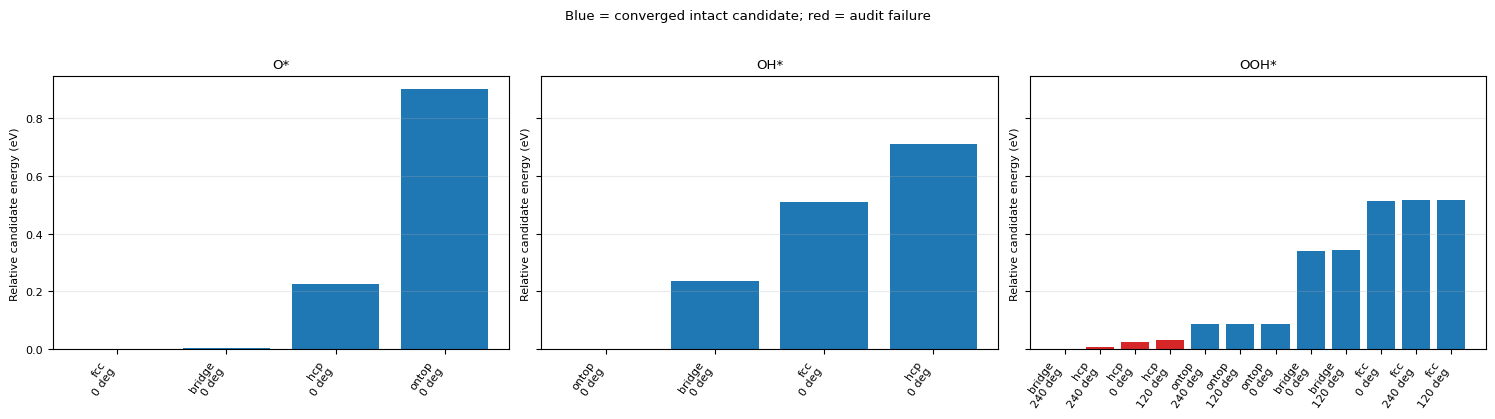

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, adsorbate in zip(axes, ["O", "OH", "OOH"]):
    group = candidates[(candidates["adsorbate"] == adsorbate) & candidates["energy_eV"].notna()].copy()
    group = group.sort_values("relative_energy_eV")
    labels = [f"{s}\n{a:g} deg" for s, a in zip(group.start_site, group.azimuth_deg)]
    colors = ["tab:blue" if ok else "tab:red" for ok in group.valid_intact_minimum]
    ax.bar(range(len(group)), group.relative_energy_eV, color=colors)
    ax.set_xticks(range(len(group)), labels, rotation=55, ha="right")
    ax.set_title(f"{adsorbate}*")
    ax.set_ylabel("Relative candidate energy (eV)")
    ax.grid(axis="y", alpha=0.25)
fig.suptitle("Blue = converged intact candidate; red = audit failure", y=1.03)
plt.tight_layout()
plt.show()


## 10. Inspect the selected structures

Plot both top and side views. Automated audit flags are useful, but visual inspection remains mandatory—especially for OOH*, which may tilt, transfer H, or approach another Pt atom.


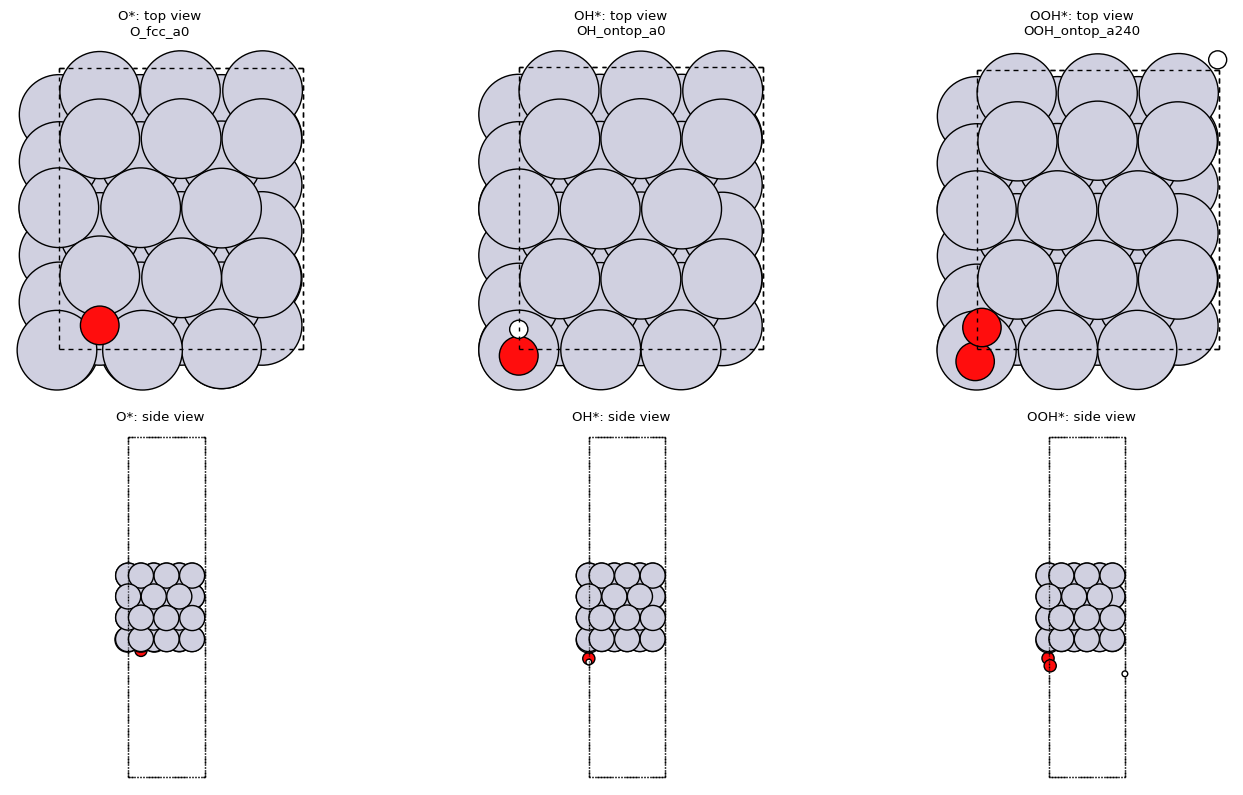

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for column, adsorbate in enumerate(["O", "OH", "OOH"]):
    label = best.loc[adsorbate, "label"]
    atoms = relaxed_structures[label]
    plot_atoms(atoms, axes[0, column], rotation="0x,0y,0z", show_unit_cell=2)
    axes[0, column].set_title(f"{adsorbate}*: top view\n{label}")
    plot_atoms(atoms, axes[1, column], rotation="90x,0y,0z", show_unit_cell=2)
    axes[1, column].set_title(f"{adsorbate}*: side view")
    axes[0, column].set_axis_off()
    axes[1, column].set_axis_off()
plt.tight_layout()
plt.show()


## 11. Calculate balanced adsorption energies

Let $E_*$ be the relaxed clean-slab energy and $E_{X*}$ the selected relaxed adsorbate-slab energy. We use these atom-balanced cycles:

$$
\Delta E_{\mathrm{OH*}} = E_{\mathrm{OH*}} - E_* - \left(E_{\mathrm{H_2O}} - \tfrac{1}{2}E_{\mathrm{H_2}}\right)
$$

$$
\Delta E_{\mathrm{O*}} = E_{\mathrm{O*}} - E_* - \left(E_{\mathrm{H_2O}} - E_{\mathrm{H_2}}\right)
$$

$$
\Delta E_{\mathrm{OOH*}} = E_{\mathrm{OOH*}} - E_* - \left(2E_{\mathrm{H_2O}} - \tfrac{3}{2}E_{\mathrm{H_2}}\right)
$$

These are electronic reaction/adsorption energies relative to H$_2$/H$_2$O. They are **not** direct radical binding energies and are **not yet** Gibbs free energies.


,intermediate,delta_E_eV,selected_label,final_site_family,chemical_slip,max_force_eVA
0,O*,1.7241,O_fcc_a0,hollow,False,0.0491
1,OH*,0.8256,OH_ontop_a0,ontop,False,0.0424
2,OOH*,4.0764,OOH_ontop_a240,ontop,False,0.0471


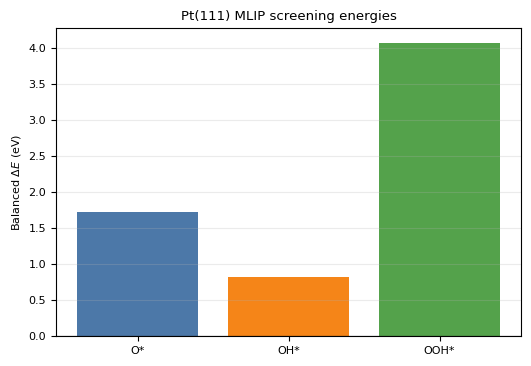

In [13]:
E_H2 = reference_energies["H2"]
E_H2O = reference_energies["H2O"]
E_ads_slab = {name: float(best.loc[name, "energy_eV"]) for name in ["O", "OH", "OOH"]}

delta_E = {
    "O*": E_ads_slab["O"] - E_CLEAN - (E_H2O - E_H2),
    "OH*": E_ads_slab["OH"] - E_CLEAN - (E_H2O - 0.5 * E_H2),
    "OOH*": E_ads_slab["OOH"] - E_CLEAN - (2.0 * E_H2O - 1.5 * E_H2),
}

summary = pd.DataFrame(
    {
        "intermediate": list(delta_E),
        "delta_E_eV": list(delta_E.values()),
        "selected_label": [best.loc[x, "label"] for x in ["O", "OH", "OOH"]],
        "final_site_family": [best.loc[x, "final_site_family"] for x in ["O", "OH", "OOH"]],
        "chemical_slip": [bool(best.loc[x, "chemical_slip"]) for x in ["O", "OH", "OOH"]],
        "max_force_eVA": [best.loc[x, "max_force_eVA"] for x in ["O", "OH", "OOH"]],
    }
)
summary.to_csv(RESULTS / "best_adsorption_energies.csv", index=False)
display(summary.style.format({"delta_E_eV": "{:.4f}", "max_force_eVA": "{:.4f}"}))

plt.figure(figsize=(6, 4))
plt.bar(summary["intermediate"], summary["delta_E_eV"], color=["#4C78A8", "#F58518", "#54A24B"])
plt.axhline(0.0, color="black", linewidth=0.8)
plt.ylabel(r"Balanced $\Delta E$ (eV)")
plt.title("Pt(111) MLIP screening energies")
plt.grid(axis="y", alpha=0.25)
plt.show()


## 12. From $\Delta E$ to electrochemical $\Delta G$

A typical computational-hydrogen-electrode bookkeeping step is

$$
\Delta G(U,\mathrm{pH}) = \Delta E + \Delta \mathrm{ZPE} - T\Delta S
+ \Delta G_{\mathrm{solv}} + \Delta G_{\mathrm{field/coverage}}
+ n e U + n k_B T\ln(10)\,\mathrm{pH},
$$

with signs chosen consistently for the written reaction direction. Do not insert generic correction numbers without documenting their source, adsorbate state, coverage, functional and solvent model. For Pt(111), explicit/implicit solvent, water orientation, electrode potential and coverage can materially alter OH*/OOH* energetics.

A robust next stage is:

1. DFT single-point energies and forces on the MLIP minima;
2. re-relax structures with large DFT residual forces;
3. convergence tests for slab size, layers, vacuum, k-points and cutoff;
4. vibrational calculations for ZPE/entropy;
5. a documented solvation/field/constant-potential treatment.


## 13. Export the best structures for DFT

Each selected structure is written as Extended XYZ and VASP POSCAR. The POSCAR does not contain your VASP settings; use the same functional, PAW datasets, cutoff, k-point density, smearing, dipole correction and convergence criteria for every term in the energy cycle.


In [15]:
export_dir = RESULTS / "dft_handoff"
export_dir.mkdir(exist_ok=True)


def export_ready_copy(atoms):
    """Create a geometry-only copy safe for EXTXYZ/VASP export."""
    exported = atoms.copy()

    # Remove stale MACE results from the shared calculator.
    exported.calc = None

    # Internal ASE adsorption-site dictionary; unnecessary for DFT export.
    exported.info.pop("adsorbate_info", None)

    return exported


# Clean Pt(111) slab
clean_export = export_ready_copy(clean_slab)

write(
    export_dir / "clean_Pt111.extxyz",
    clean_export,
    write_results=False,
)

write(
    export_dir / "POSCAR_clean_Pt111",
    clean_export,
    format="vasp",
    direct=True,
    vasp5=True,
)


# H2 and H2O references
for name, atoms in reference_structures.items():
    write(
        export_dir / f"{name}.extxyz",
        export_ready_copy(atoms),
        write_results=False,
    )


# Selected O*, OH* and OOH* structures
for adsorbate in ["O", "OH", "OOH"]:
    label = best.loc[adsorbate, "label"]
    atoms = export_ready_copy(relaxed_structures[label])

    write(
        export_dir / f"best_{adsorbate}.extxyz",
        atoms,
        write_results=False,
    )

    write(
        export_dir / f"POSCAR_best_{adsorbate}",
        atoms,
        format="vasp",
        direct=True,
        vasp5=True,
    )


# Compress and download all results
archive = shutil.make_archive(
    "pt111_mace_results",
    "zip",
    RESULTS,
)

print("Created:", archive)

try:
    from google.colab import files
    files.download(archive)
except ImportError:
    print("Outside Colab: download the ZIP from the notebook file browser.")

Created: /content/pt111_mace_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 14. DFT residual-force validation template

After a DFT single-point calculation on each MLIP minimum, inspect the largest force. Fako *et al.* use this MLIP-relaxation → DFT-force comparison to identify configurations that need higher-level refinement or active-learning data.

The exact threshold is project-specific. As a practical diagnostic, a large DFT residual force (for example, much larger than your target DFT relaxation tolerance) means that the MLIP and DFT minima disagree locally.


In [18]:
def dft_residual_force_report(dft_forces_eVA, fixed_indices=()):
    '''Summarize forces parsed from a DFT calculation.

    Parameters
    ----------
    dft_forces_eVA : array-like, shape (N, 3)
        DFT forces in eV/Angstrom on the MLIP-relaxed geometry.
    fixed_indices : iterable of int
        Atoms constrained during the surface relaxation.
    '''
    forces = np.asarray(dft_forces_eVA, dtype=float)
    movable = np.ones(len(forces), dtype=bool)
    movable[list(fixed_indices)] = False
    norms = np.linalg.norm(forces[movable], axis=1)
    return {
        "max_DFT_residual_force_eVA": float(norms.max()),
        "rms_DFT_residual_force_eVA": float(np.sqrt(np.mean(norms**2))),
        "n_movable_atoms": int(movable.sum()),
    }

# Example after parsing a DFT output with ASE:
# dft_atoms = read("vasprun.xml")
# report = dft_residual_force_report(
#     dft_atoms.get_forces(), fixed_indices=constrained_indices(clean_slab)
# )
# print(report)


## Interpretation checklist

Before reporting a value, ask:

- Did every selected candidate converge below the chosen force threshold?
- Was the final site relabeled after relaxation?
- Did OH*/OOH* remain intact, or did H/O transfer create a different state?
- Did several starting sites/orientations converge to the same minimum?
- Are all energy-cycle terms from the same MACE model and head?
- Are DFT residual forces acceptably small?
- Have slab, coverage, k-point and thermochemical/solvation corrections been converged?

**Suggested extensions:** more OOH tilt angles, water co-adsorption, bridge-bound OOH, defects/steps, coverage sweeps, NEB barriers, uncertainty/committee models, and active learning with DFT residuals.
